# Exploratory Data Analysis (EDA) — Sri Lanka Property Price Predictor

This notebook explores the cleaned dataset through statistical summaries and visualizations to understand feature distributions, correlations, and patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

DATA_DIR = os.path.join('..', 'data')
df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (15003, 7)


,Bedrooms,Bathrooms,Land_Size_Perches,House_Size_Sqft,City,District,Price_LKR
0,3,1,50.0,1600.0,109,15,5400000.0
1,3,3,8.0,1480.0,10,4,16800000.0
2,3,2,20.0,2800.0,92,6,20000000.0
3,5,5,22.0,4000.0,36,4,187000000.0
4,4,4,11.0,3300.0,152,4,55000000.0


## 1. Dataset Overview

In [2]:
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print(f'\n=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
Shape: (15003, 7)

=== Data Types ===
Bedrooms               int64
Bathrooms              int64
Land_Size_Perches    float64
House_Size_Sqft      float64
City                   int64
District               int64
Price_LKR            float64
dtype: object

=== Missing Values ===
Bedrooms             0
Bathrooms            0
Land_Size_Perches    0
House_Size_Sqft      0
City                 0
District             0
Price_LKR            0
dtype: int64

=== Statistical Summary ===


,Bedrooms,Bathrooms,Land_Size_Perches,House_Size_Sqft,City,District,Price_LKR
count,15003.000000,15003.000000,15003.000000,15003.000000,15003.00000,15003.000000,1.500300e+04
mean,3.986203,2.976805,13.212529,2703.757594,104.18483,4.841965,3.317354e+07
std,1.231560,1.335374,14.282121,1436.572377,44.02012,2.039477,2.847001e+07
min,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,3.500000e+06
25%,3.000000,2.000000,7.800000,1650.000000,78.00000,4.000000,1.650000e+07
50%,4.000000,3.000000,10.000000,2500.000000,106.00000,4.000000,2.600000e+07
75%,4.000000,4.000000,14.000000,3250.000000,141.00000,6.000000,3.800000e+07
max,10.000000,10.000000,480.000000,20000.000000,169.00000,23.000000,1.900000e+08


## 2. Target Variable Distribution (Price)

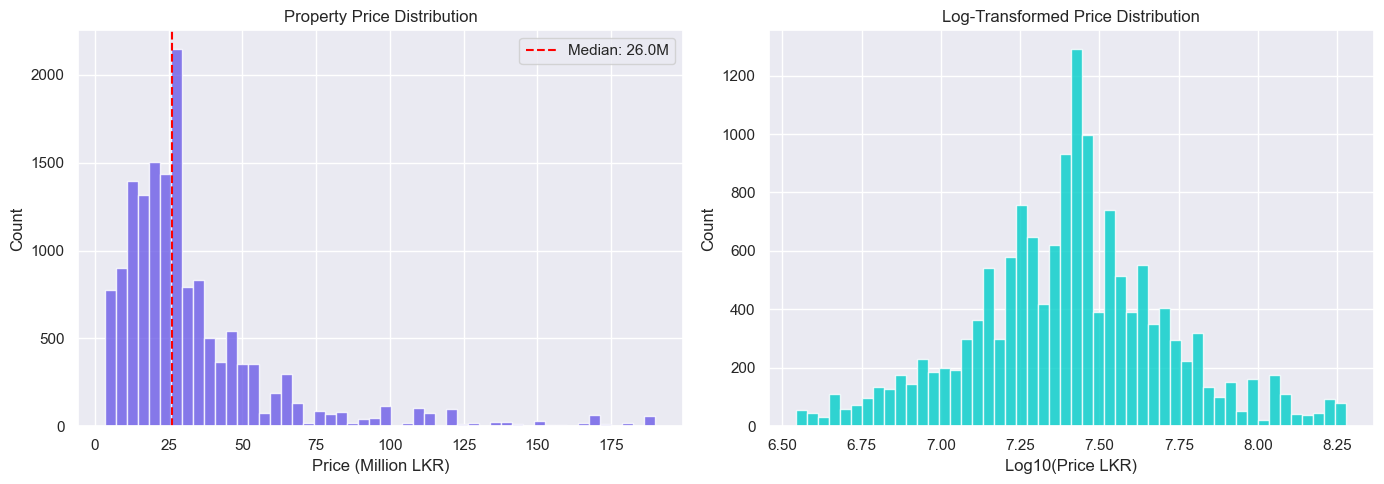

Price Statistics (Million LKR):
  Mean:   33.17M
  Median: 26.00M
  Std:    28.47M
  Min:    3.50M
  Max:    190.00M


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
axes[0].hist(df['Price_LKR'] / 1e6, bins=50, color='#6c5ce7', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Price (Million LKR)')
axes[0].set_ylabel('Count')
axes[0].set_title('Property Price Distribution')
axes[0].axvline(x=df['Price_LKR'].median() / 1e6, color='red', linestyle='--', label=f'Median: {df["Price_LKR"].median()/1e6:.1f}M')
axes[0].legend()

# Log-transformed price
axes[1].hist(np.log10(df['Price_LKR']), bins=50, color='#00cec9', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Log10(Price LKR)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Transformed Price Distribution')

plt.tight_layout()
plt.show()

print(f'Price Statistics (Million LKR):')
print(f'  Mean:   {df["Price_LKR"].mean()/1e6:.2f}M')
print(f'  Median: {df["Price_LKR"].median()/1e6:.2f}M')
print(f'  Std:    {df["Price_LKR"].std()/1e6:.2f}M')
print(f'  Min:    {df["Price_LKR"].min()/1e6:.2f}M')
print(f'  Max:    {df["Price_LKR"].max()/1e6:.2f}M')

## 3. Feature Distributions

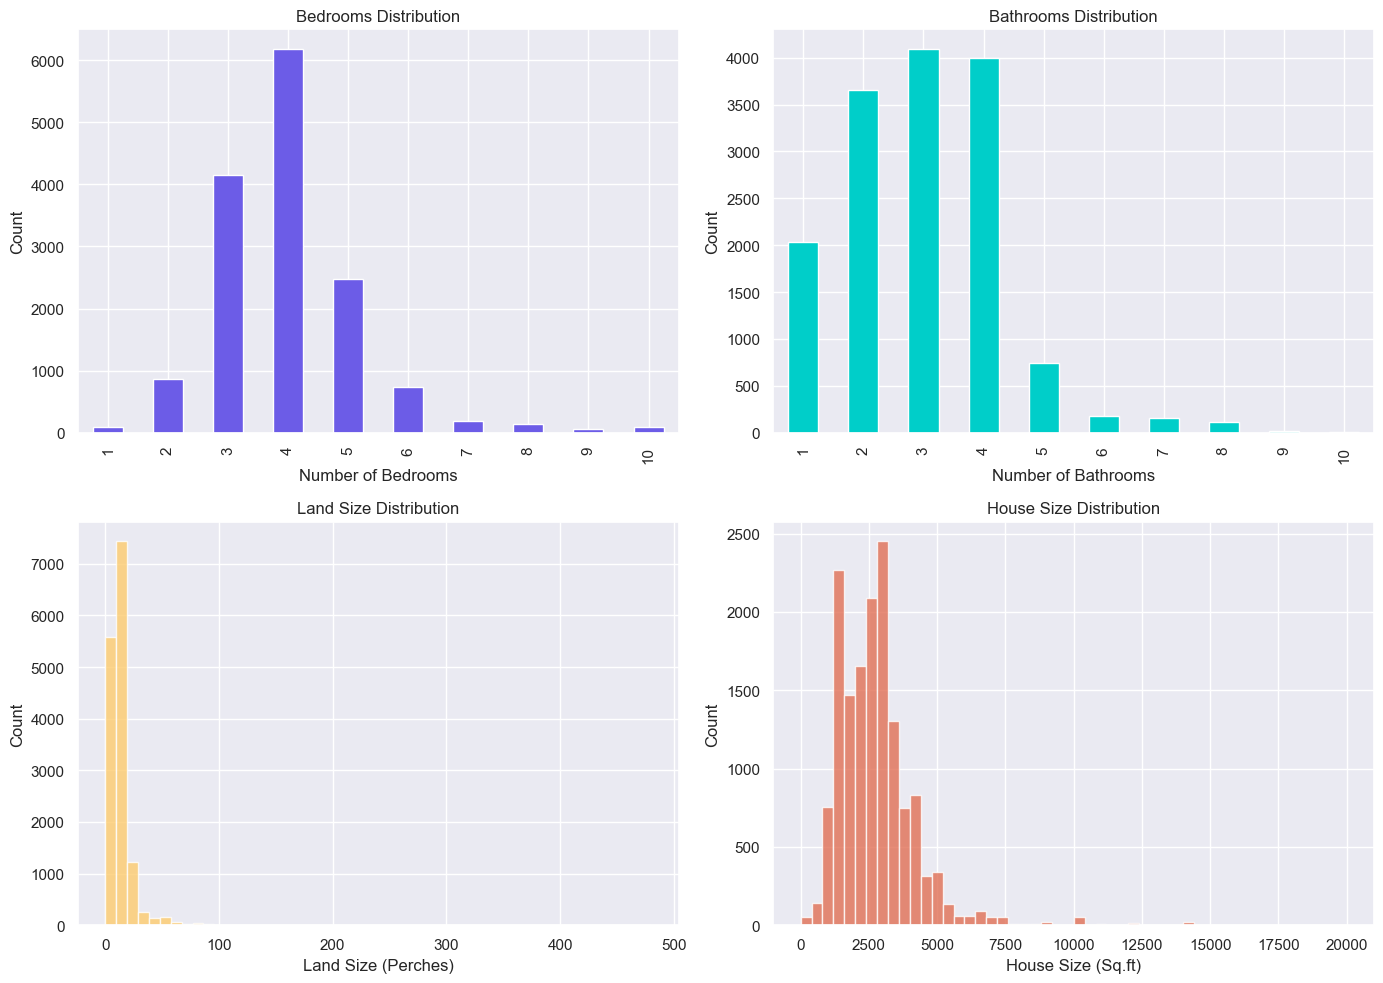

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bedrooms
df['Bedrooms'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='#6c5ce7')
axes[0,0].set_title('Bedrooms Distribution')
axes[0,0].set_xlabel('Number of Bedrooms')
axes[0,0].set_ylabel('Count')

# Bathrooms
df['Bathrooms'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='#00cec9')
axes[0,1].set_title('Bathrooms Distribution')
axes[0,1].set_xlabel('Number of Bathrooms')
axes[0,1].set_ylabel('Count')

# Land Size
axes[1,0].hist(df['Land_Size_Perches'], bins=50, color='#fdcb6e', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Land Size Distribution')
axes[1,0].set_xlabel('Land Size (Perches)')
axes[1,0].set_ylabel('Count')

# House Size
axes[1,1].hist(df['House_Size_Sqft'], bins=50, color='#e17055', edgecolor='white', alpha=0.8)
axes[1,1].set_title('House Size Distribution')
axes[1,1].set_xlabel('House Size (Sq.ft)')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Price by District

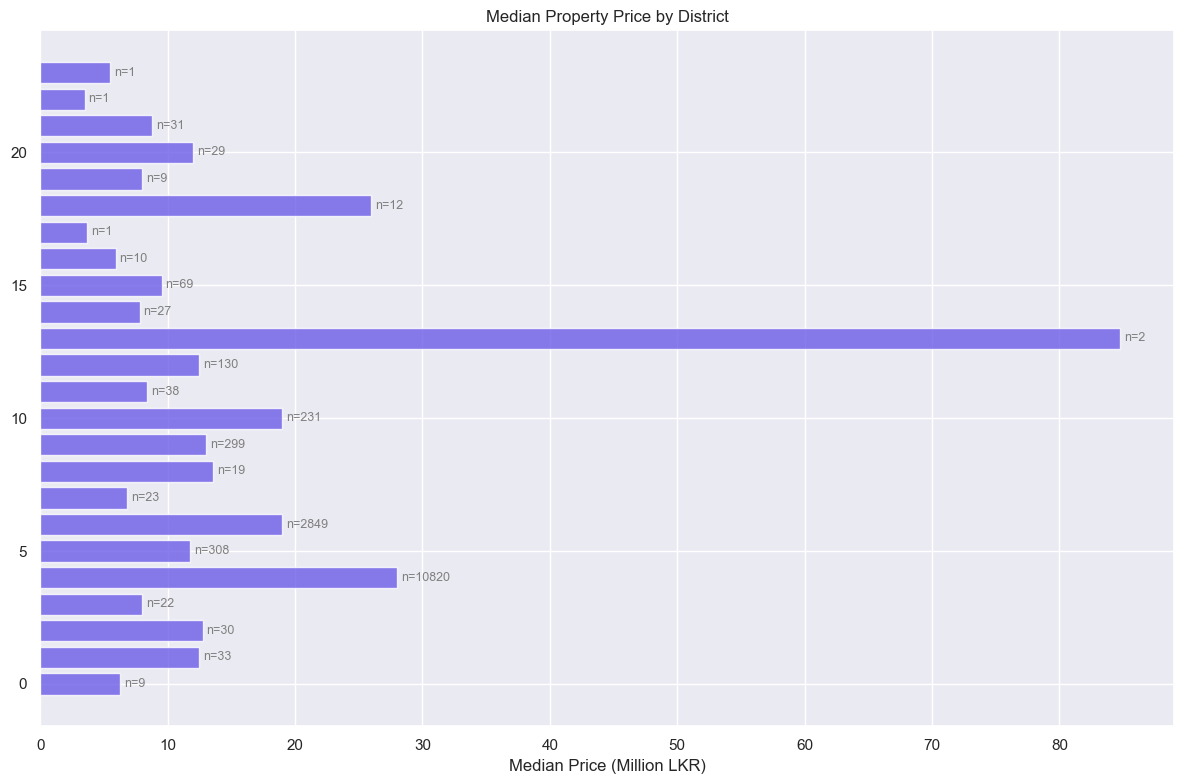

In [5]:
district_stats = df.groupby('District')['Price_LKR'].agg(['median', 'count']).reset_index()
district_stats.columns = ['District', 'Median_Price', 'Count']
district_stats = district_stats.sort_values('Median_Price', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(district_stats['District'], district_stats['Median_Price'] / 1e6, color='#6c5ce7', alpha=0.8)
ax.set_xlabel('Median Price (Million LKR)')
ax.set_title('Median Property Price by District')

# Add count labels
for bar, count in zip(bars, district_stats['Count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'n={count}',
            va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

## 5. Top 15 Cities by Listing Count

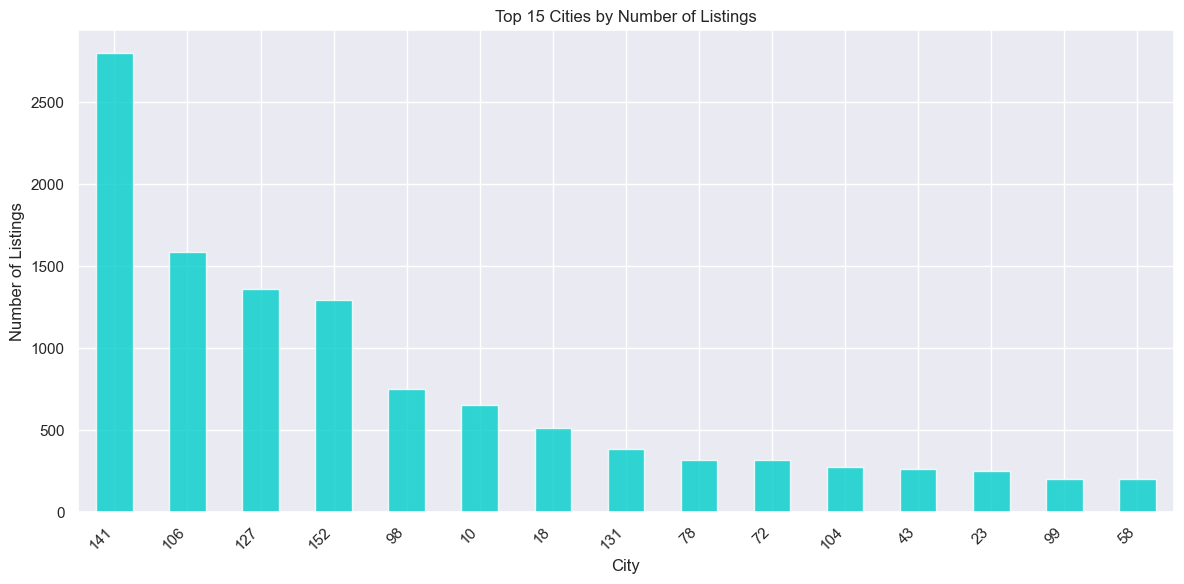

In [6]:
top_cities = df['City'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_cities.plot(kind='bar', ax=ax, color='#00cec9', alpha=0.8)
ax.set_title('Top 15 Cities by Number of Listings')
ax.set_xlabel('City')
ax.set_ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

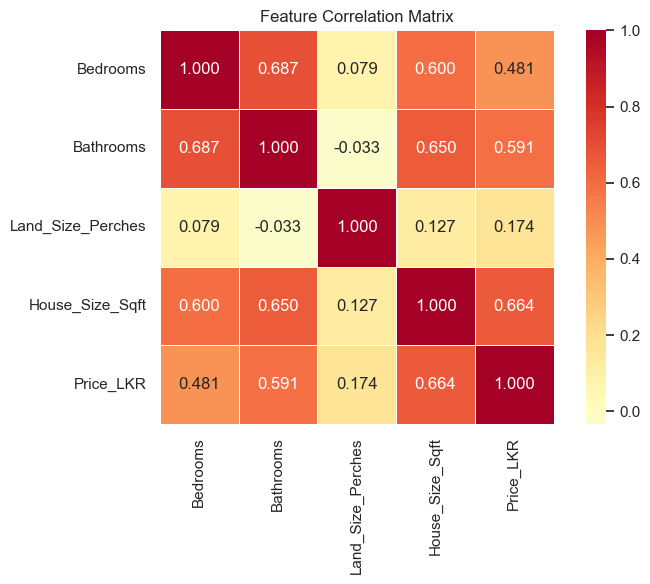


Correlation with Price:
Price_LKR            1.000000
House_Size_Sqft      0.664364
Bathrooms            0.591142
Bedrooms             0.480522
Land_Size_Perches    0.174239
Name: Price_LKR, dtype: float64


In [7]:
numeric_cols = ['Bedrooms', 'Bathrooms', 'Land_Size_Perches', 'House_Size_Sqft', 'Price_LKR']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nCorrelation with Price:')
print(corr_matrix['Price_LKR'].sort_values(ascending=False))

## 7. Price vs Features Scatter Plots

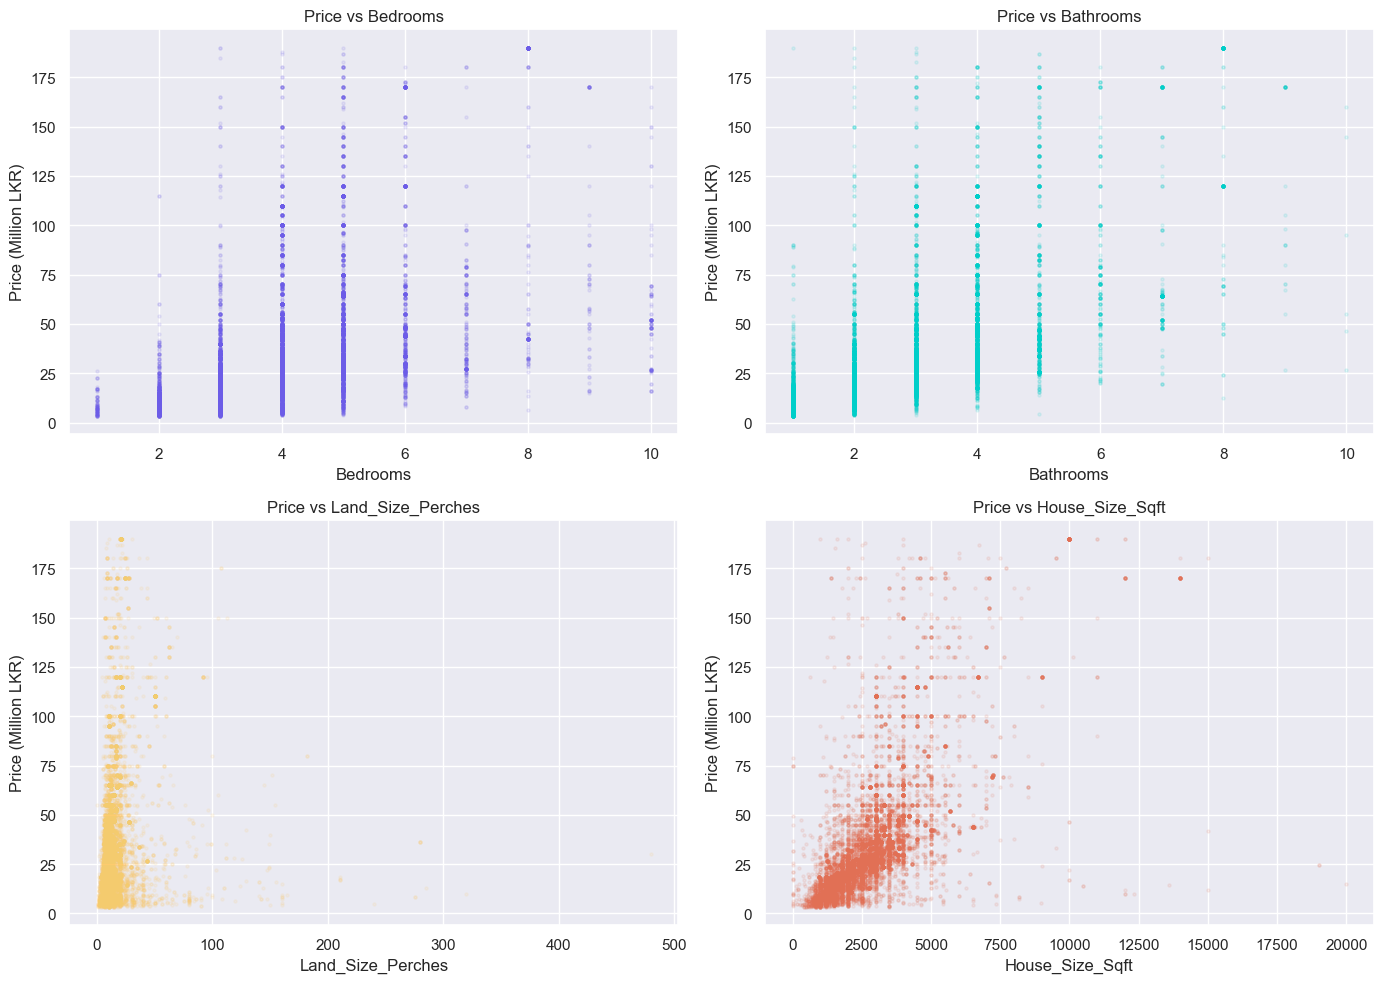

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = ['Bedrooms', 'Bathrooms', 'Land_Size_Perches', 'House_Size_Sqft']
colors = ['#6c5ce7', '#00cec9', '#fdcb6e', '#e17055']

for ax, feat, color in zip(axes.flatten(), features, colors):
    ax.scatter(df[feat], df['Price_LKR'] / 1e6, alpha=0.1, s=5, color=color)
    ax.set_xlabel(feat)
    ax.set_ylabel('Price (Million LKR)')
    ax.set_title(f'Price vs {feat}')

plt.tight_layout()
plt.show()

## 8. Box Plots — Price by Bedrooms/Bathrooms

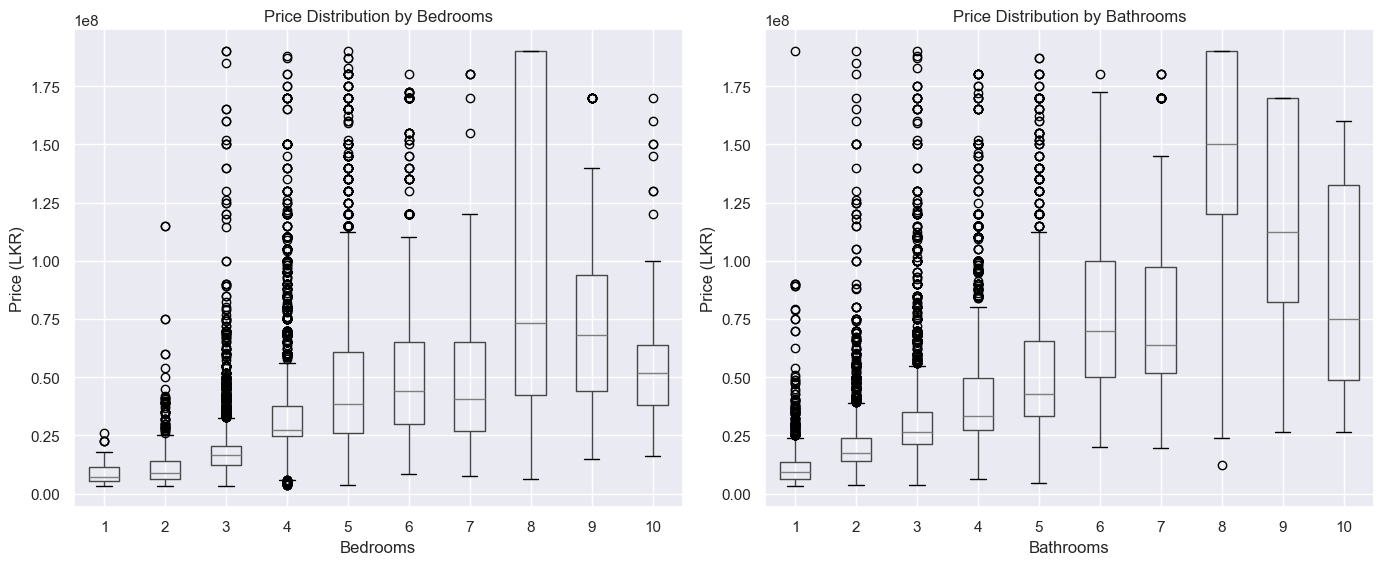

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df.boxplot(column='Price_LKR', by='Bedrooms', ax=axes[0])
axes[0].set_title('Price Distribution by Bedrooms')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Price (LKR)')

df.boxplot(column='Price_LKR', by='Bathrooms', ax=axes[1])
axes[1].set_title('Price Distribution by Bathrooms')
axes[1].set_xlabel('Bathrooms')
axes[1].set_ylabel('Price (LKR)')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 9. Key Insights

1. **Price distribution** is right-skewed — most properties are under 50M LKR.
2. **Colombo** and **Gampaha** districts dominate the dataset and have the highest prices.
3. **House size** and **land size** show strong positive correlation with price.
4. **Bathrooms** correlate more strongly with price than bedrooms.
5. **3-4 bedroom** houses are the most common in the dataset.